# NB11 — Two-Stage Horizon Sweep

NB10's null result at 1h could be either of two things:

1. **Hypothesis-wrong:** predicted transitions don't carry return-prediction signal at any horizon.
2. **Scope-limited:** predicted transitions need substantive transitions to predict, and at 1h transitions are too rare.

NB11 disambiguates by running NB10's pipeline at horizons {1, 4, 24} hours. If `transition_rf` IC ≥ `hierarchy_rf` IC at the longer horizons but ties at 1h, hypothesis 2 wins and the architecture is *qualified, not wrong*. If null everywhere, hypothesis 1 wins.

**Setup:** same as NB10 (BTC-USD hourly, 5-fold walk-forward, 50/50 stage split, K=4 hierarchy, RF Stage-1 and Stage-2 with fixed hyperparameters). The only change is `HORIZONS = [1, 4, 24]`.


In [1]:
import math, os, json, random
from dataclasses import dataclass
from datetime import datetime
from typing import List, Dict, Tuple, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error,
    accuracy_score, balanced_accuracy_score, roc_auc_score,
)
from scipy.stats import spearmanr

SEED = 42
random.seed(SEED); np.random.seed(SEED)

TICKER = "BTC-USD"
PERIOD = "720d"
INTERVAL = "1h"

HORIZONS = [1, 4, 24]
N_FOLDS = 5
MIN_TRAIN_FRACTION = 0.40
TEST_FRACTION_PER_FOLD = 0.10
F1_F2_SPLIT = 0.5

MAX_HIERARCHY_DEPTH = 2
MIN_LEAF_COUNT = 200

RF_N_ESTIMATORS = 200
STAGE1_PARAMS = {"max_depth": 8, "min_samples_leaf": 20}
STAGE2_PARAMS = {"max_depth": 8, "min_samples_leaf": 20}

JOURNAL_PATH = "EXPERIMENTS.md"


## Reused helpers (identical to NB10)


In [2]:
def load_yfinance_hourly(ticker, period, interval):
    raw = yf.download(tickers=ticker, period=period, interval=interval,
                     auto_adjust=True, progress=False, group_by="column")
    if raw.empty: raise RuntimeError(f"No data for {ticker}")
    if isinstance(raw.columns, pd.MultiIndex):
        raw.columns = [c[0].lower() for c in raw.columns]
    else:
        raw.columns = [str(c).lower() for c in raw.columns]
    df = raw[["open","high","low","close","volume"]].copy().reset_index()
    ts_col = [c for c in df.columns if c not in ("open","high","low","close","volume")][0]
    df = df.rename(columns={ts_col: "ts"})
    df["ts"] = pd.to_datetime(df["ts"], utc=True)
    return df.dropna().sort_values("ts").reset_index(drop=True)


def rolling_zscore(x, w, eps=1e-8):
    m = x.rolling(w, min_periods=max(3, w // 3)).mean()
    s = x.rolling(w, min_periods=max(3, w // 3)).std()
    return (x - m) / (s + eps)


def sigmoid_np(x): return 1.0 / (1.0 + np.exp(-x))


def make_hourly_features(df, horizons):
    out = df.copy()
    for lag in (1, 2, 4, 12, 24, 168):
        out[f"ret_{lag}"] = np.log(out["close"] / out["close"].shift(lag))
    out["range_pct"] = (out["high"] - out["low"]) / out["close"]
    out["open_close_pct"] = (out["close"] - out["open"]) / out["open"]
    for w in (24, 168, 720):
        out[f"vol_{w}"] = out["ret_1"].rolling(w).std()
    for w in (24, 168, 720):
        out[f"ma_{w}"] = out["close"].rolling(w).mean()
        out[f"price_to_ma_{w}"] = out["close"] / out[f"ma_{w}"] - 1.0
    out["volume_log"] = np.log1p(out["volume"])
    out["volume_z_168"] = rolling_zscore(out["volume_log"], 168)
    for w in (168, 720):
        out[f"rolling_max_{w}"] = out["close"].rolling(w).max()
        out[f"drawdown_{w}"] = out["close"] / out[f"rolling_max_{w}"] - 1.0
    out["trend_pressure"] = rolling_zscore(out["ret_168"], 720)
    out["fear_pressure"] = (-4.0*out["drawdown_168"] - 2.0*out["drawdown_720"]
                              + 8.0*out["vol_168"] + 0.35*out["volume_z_168"]
                              - 0.50*out["ret_24"])
    out["greed_pressure"] = (1.50*out["trend_pressure"] + 2.00*out["price_to_ma_168"]
                              + 1.00*out["ret_168"] + 0.20*out["volume_z_168"]
                              - 3.00*out["vol_720"])
    out["fear_index"] = sigmoid_np(out["fear_pressure"].clip(-8, 8))
    out["greed_index"] = sigmoid_np(out["greed_pressure"].clip(-8, 8))
    # Compute one target pair per horizon
    for h in horizons:
        out[f"future_log_return_{h}"] = np.log(out["close"].shift(-h) / out["close"])
        out[f"future_direction_{h}"] = (out[f"future_log_return_{h}"] > 0).astype(int)
    return out.replace([np.inf, -np.inf], np.nan).dropna().reset_index(drop=True)


BASELINE_FEATURES = [
    "ret_1", "ret_2", "ret_4", "ret_12", "ret_24", "ret_168",
    "range_pct", "open_close_pct",
    "vol_24", "vol_168", "vol_720",
    "price_to_ma_24", "price_to_ma_168", "price_to_ma_720",
    "volume_z_168", "drawdown_168", "drawdown_720",
]


@dataclass
class MeasureNode:
    node_id: str; depth: int
    bounds: Dict[str, Tuple[float, float]]
    mass: float; count: int
    mean: Dict[str, float]
    children: Optional[List["MeasureNode"]] = None
    @property
    def is_leaf(self): return not self.children


def in_bounds(row, bounds):
    for col, (lo, hi) in bounds.items():
        v = float(row[col])
        if not (lo <= v < hi): return False
    return True


def split_node(n, sc, sv):
    lo, hi = n.bounds[sc]
    lb, rb = dict(n.bounds), dict(n.bounds)
    lb[sc] = (lo, sv); rb[sc] = (sv, hi)
    n.children = [
        MeasureNode(n.node_id+"L", n.depth+1, lb, n.mass/2, 0, {}, None),
        MeasureNode(n.node_id+"R", n.depth+1, rb, n.mass/2, 0, {}, None),
    ]
    return n.children


def collect_leaves(n):
    if n.is_leaf: return [n]
    return [l for c in n.children for l in collect_leaves(c)]


def build_hierarchy(train_df, max_depth, min_count):
    feat = ["greed_index", "fear_index"]
    root = MeasureNode("root", 0,
                       {"greed_index":(0.0,1.000001), "fear_index":(0.0,1.000001)},
                       1.0, len(train_df),
                       {c: float(train_df[c].mean()) for c in feat}, None)
    queue = [root]
    while queue:
        n = queue.pop(0)
        if n.depth >= max_depth: continue
        mask = train_df.apply(lambda r: in_bounds(r, n.bounds), axis=1)
        sub = train_df[mask]
        n.count = len(sub); n.mass = n.count / max(len(train_df), 1)
        if n.count < min_count: continue
        v = {c: float(sub[c].var()) for c in feat}
        sc = max(v, key=v.get); sv = float(sub[sc].median())
        if n.bounds[sc][0] < sv < n.bounds[sc][1]:
            queue.extend(split_node(n, sc, sv))
    for leaf in collect_leaves(root):
        mask = train_df.apply(lambda r: in_bounds(r, leaf.bounds), axis=1)
        sub = train_df[mask]
        leaf.count = len(sub); leaf.mass = leaf.count / max(len(train_df), 1)
        leaf.mean = {c: (float(sub[c].mean()) if len(sub) else 0.0) for c in feat}
    return root


def soft_membership(row, leaves, temperature=0.04):
    p = np.array([float(row["greed_index"]), float(row["fear_index"])])
    centers = np.array([[(l.bounds["greed_index"][0]+l.bounds["greed_index"][1])/2,
                          (l.bounds["fear_index"][0]+l.bounds["fear_index"][1])/2]
                         for l in leaves])
    d = np.sum((centers - p[None,:])**2, axis=1)
    logits = -d / max(temperature, 1e-8); logits -= logits.max()
    w = np.exp(logits); return w / w.sum()


def add_memberships(frame, leaves, cols):
    M = np.vstack([soft_membership(r, leaves) for _, r in frame.iterrows()])
    return pd.concat([frame.reset_index(drop=True),
                      pd.DataFrame(M, columns=cols).reset_index(drop=True)], axis=1)


def assign_leaf_index(row, leaves):
    for i, leaf in enumerate(leaves):
        if in_bounds(row, leaf.bounds): return i
    return -1


def make_folds(n_rows, n_folds, min_train_fraction, test_fraction_per_fold):
    folds = []
    for i in range(n_folds):
        train_end = int(n_rows * (min_train_fraction + i * test_fraction_per_fold))
        test_end = int(n_rows * (min_train_fraction + (i + 1) * test_fraction_per_fold))
        if test_end > n_rows: test_end = n_rows
        if test_end - train_end < 50: break
        folds.append((train_end, test_end))
    return folds


def ic(y_true, y_pred):
    if np.std(y_pred) == 0: return 0.0
    rho, _ = spearmanr(y_true, y_pred)
    return float(rho) if not np.isnan(rho) else 0.0


def derive_transition_features(probs, state_t, leaf_centers, K):
    eps = 1e-12
    entropy_vals = -np.sum(probs * np.log(probs + eps), axis=1)
    p_same = probs[np.arange(len(probs)), state_t]
    instability = 1.0 - p_same
    state_indices = np.arange(K)
    expected_state_idx = probs @ state_indices
    delta_index = expected_state_idx - state_t.astype(float)
    expected_center = probs @ leaf_centers
    current_center = leaf_centers[state_t]
    drift = expected_center - current_center
    sorted_probs = np.sort(probs, axis=1)[:, ::-1]
    margin = sorted_probs[:, 0] - sorted_probs[:, 1]
    argmax_state = probs.argmax(axis=1)
    state_change = (argmax_state != state_t).astype(int)
    out = {f"trans_prob_{i}": probs[:, i] for i in range(K)}
    out.update({
        "trans_entropy": entropy_vals,
        "trans_instability": instability,
        "trans_delta_index": delta_index,
        "trans_drift_greed": drift[:, 0],
        "trans_drift_fear": drift[:, 1],
        "trans_margin": margin,
        "trans_state_change": state_change,
    })
    return pd.DataFrame(out)


TRANSITION_FEATURE_NAMES_TEMPLATE = (
    lambda K: [f"trans_prob_{i}" for i in range(K)] + [
        "trans_entropy", "trans_instability", "trans_delta_index",
        "trans_drift_greed", "trans_drift_fear", "trans_margin", "trans_state_change",
    ]
)


def _rf_reg(params=STAGE2_PARAMS):
    return RandomForestRegressor(n_estimators=RF_N_ESTIMATORS, random_state=SEED, n_jobs=-1, **params)

def _rf_cls(params=STAGE2_PARAMS):
    return RandomForestClassifier(n_estimators=RF_N_ESTIMATORS, random_state=SEED, n_jobs=-1,
                                   class_weight="balanced_subsample", **params)


## Per-(horizon, fold) runner


In [3]:
def run_one_fold_horizon(df_feat, fold_idx, train_end, test_end, horizon):
    target_reg = f"future_log_return_{horizon}"
    target_cls = f"future_direction_{horizon}"
    train = df_feat.iloc[:train_end].copy()
    test = df_feat.iloc[train_end:test_end].copy()

    root = build_hierarchy(train, MAX_HIERARCHY_DEPTH, MIN_LEAF_COUNT)
    leaves = collect_leaves(root)
    K = len(leaves)
    leaf_cols = [f"leaf_{l.node_id}" for l in leaves]
    leaf_centers = np.array([[(l.bounds["greed_index"][0]+l.bounds["greed_index"][1])/2,
                                (l.bounds["fear_index"][0]+l.bounds["fear_index"][1])/2]
                               for l in leaves])
    train_m = add_memberships(train, leaves, leaf_cols)
    test_m = add_memberships(test, leaves, leaf_cols)

    train_m["state_t"] = train_m.apply(lambda r: assign_leaf_index(r, leaves), axis=1)
    test_m["state_t"] = test_m.apply(lambda r: assign_leaf_index(r, leaves), axis=1)
    train_m["state_t_future"] = train_m["state_t"].shift(-horizon)
    train_m = train_m.dropna(subset=["state_t_future"]).reset_index(drop=True)
    train_m["state_t_future"] = train_m["state_t_future"].astype(int)
    train_m["state_t"] = train_m["state_t"].astype(int)
    test_m["state_t"] = test_m["state_t"].astype(int)

    mid = int(len(train_m) * F1_F2_SPLIT)
    s1_train = train_m.iloc[:mid].copy()
    s2_train = train_m.iloc[mid:].copy()

    s1_features = BASELINE_FEATURES + leaf_cols
    f1 = _rf_cls(STAGE1_PARAMS)
    f1.fit(s1_train[s1_features], s1_train["state_t_future"])

    classes_seen = list(f1.classes_)
    full_probs = lambda P: pd.DataFrame(P, columns=[f"_c{c}" for c in classes_seen]).reindex(
        columns=[f"_c{c}" for c in range(K)], fill_value=0.0
    ).to_numpy()
    s2_train_probs = full_probs(f1.predict_proba(s2_train[s1_features]))
    test_probs = full_probs(f1.predict_proba(test_m[s1_features]))

    s2_train_trans = derive_transition_features(
        s2_train_probs, s2_train["state_t"].to_numpy(), leaf_centers, K
    )
    test_trans = derive_transition_features(
        test_probs, test_m["state_t"].to_numpy(), leaf_centers, K
    )
    s2_train = pd.concat([s2_train.reset_index(drop=True), s2_train_trans.reset_index(drop=True)], axis=1)
    test_m = pd.concat([test_m.reset_index(drop=True), test_trans.reset_index(drop=True)], axis=1)

    # f1 hourly state-prediction sanity check (on s2_train)
    f1_acc = float(accuracy_score(s2_train["state_t_future"], f1.predict(s2_train[s1_features])))
    f1_persistence_acc = float((s2_train["state_t"] == s2_train["state_t_future"]).mean())

    trans_cols = TRANSITION_FEATURE_NAMES_TEMPLATE(K)
    feature_sets = [
        ("baseline_rf", BASELINE_FEATURES),
        ("hierarchy_rf", BASELINE_FEATURES + leaf_cols),
        ("transition_rf", BASELINE_FEATURES + leaf_cols + trans_cols),
    ]
    y_r = test_m[target_reg].to_numpy()
    y_c = test_m[target_cls].to_numpy().astype(int)

    rows = []
    for name, fcols in feature_sets:
        reg = _rf_reg(); reg.fit(s2_train[fcols], s2_train[target_reg])
        cls = _rf_cls(); cls.fit(s2_train[fcols], s2_train[target_cls].astype(int))
        pred_r = reg.predict(test_m[fcols])
        pred_c = cls.predict(test_m[fcols])
        prob_c = cls.predict_proba(test_m[fcols])[:, 1] if 1 in cls.classes_ else np.full(len(y_c), 0.5)
        rows.append({"horizon": horizon, "fold": fold_idx, "model": name, "kind": "regression",
                     "mae": float(mean_absolute_error(y_r, pred_r)),
                     "rmse": float(math.sqrt(mean_squared_error(y_r, pred_r))),
                     "ic": ic(y_r, pred_r), "n_test": len(y_r)})
        rows.append({"horizon": horizon, "fold": fold_idx, "model": name, "kind": "classification",
                     "accuracy": float(accuracy_score(y_c, pred_c)),
                     "balanced_accuracy": float(balanced_accuracy_score(y_c, pred_c)),
                     "roc_auc": float(roc_auc_score(y_c, prob_c)) if len(np.unique(y_c)) == 2 else float("nan"),
                     "n_test": len(y_c)})

    # Trivial baselines
    pr_zero = np.zeros_like(y_r)
    pr_pers = test_m[f"ret_{horizon}" if horizon in (1, 2, 4, 12, 24, 168) else "ret_1"].to_numpy()
    majority = int(s2_train[target_cls].mean() >= 0.5)
    pc_majority = np.full_like(y_c, majority)
    pc_pers = (pr_pers > 0).astype(int)
    for name, pr in [("zero", pr_zero), ("persistence", pr_pers)]:
        rows.append({"horizon": horizon, "fold": fold_idx, "model": name, "kind": "regression",
                     "mae": float(mean_absolute_error(y_r, pr)),
                     "rmse": float(math.sqrt(mean_squared_error(y_r, pr))),
                     "ic": ic(y_r, pr), "n_test": len(y_r)})
    for name, pc in [("majority", pc_majority), ("persistence", pc_pers)]:
        rows.append({"horizon": horizon, "fold": fold_idx, "model": name, "kind": "classification",
                     "accuracy": float(accuracy_score(y_c, pc)),
                     "balanced_accuracy": float(balanced_accuracy_score(y_c, pc)),
                     "roc_auc": float("nan"),
                     "n_test": len(y_c)})

    info = {"f1_accuracy_on_s2": f1_acc, "f1_persistence_acc_on_s2": f1_persistence_acc, "K": K}
    return pd.DataFrame(rows), info


## Run the full (horizon × fold) grid


In [4]:
df_raw = load_yfinance_hourly(TICKER, PERIOD, INTERVAL)
df_feat = make_hourly_features(df_raw, HORIZONS)
print(f"{TICKER}: {len(df_raw)} raw -> {len(df_feat)} bars after dropna")

folds = make_folds(len(df_feat), N_FOLDS, MIN_TRAIN_FRACTION, TEST_FRACTION_PER_FOLD)
print(f"{len(folds)} folds")

all_rows, all_info = [], []
for h in HORIZONS:
    for i, (tr, te) in enumerate(folds):
        print(f"horizon={h}h fold={i}")
        rdf, info = run_one_fold_horizon(df_feat, i, tr, te, h)
        all_rows.append(rdf)
        info["horizon"] = h; info["fold"] = i
        all_info.append(info)

agg = pd.concat(all_rows, ignore_index=True)
agg.tail(20)


BTC-USD: 17101 raw -> 16357 bars after dropna
5 folds
horizon=1h fold=0


horizon=1h fold=1


horizon=1h fold=2


horizon=1h fold=3


horizon=1h fold=4


...

horizon=24h fold=1


horizon=24h fold=2


horizon=24h fold=3


horizon=24h fold=4


,horizon,fold,model,kind,mae,rmse,ic,n_test,accuracy,balanced_accuracy,roc_auc
130,24,3,baseline_rf,regression,0.023678,0.031835,0.166737,1636,NaN,NaN,NaN
131,24,3,baseline_rf,classification,NaN,NaN,NaN,1636,0.540954,0.553306,0.599030
132,24,3,hierarchy_rf,regression,0.023720,0.031892,0.158564,1636,NaN,NaN,NaN
133,24,3,hierarchy_rf,classification,NaN,NaN,NaN,1636,0.526895,0.540802,0.581438
134,24,3,transition_rf,regression,0.023718,0.031851,0.165880,1636,NaN,NaN,NaN
135,24,3,transition_rf,classification,NaN,NaN,NaN,1636,0.498166,0.510296,0.526245
136,24,3,zero,regression,0.018843,0.027001,0.000000,1636,NaN,NaN,NaN
137,24,3,persistence,regression,0.028976,0.039604,-0.055484,1636,NaN,NaN,NaN
138,24,3,majority,classification,NaN,NaN,NaN,1636,0.475550,0.500000,NaN
139,24,3,persistence,classification,NaN,NaN,NaN,1636,0.510391,0.509128,NaN


## Stage-1 state-prediction sanity per (horizon, fold)

If transition-feature contribution should grow with horizon, the precondition is that `f1` is meaningfully better than persistence at predicting `z_{t+h}` for that horizon. Show those numbers up front.


In [5]:
info_df = pd.DataFrame(all_info)
info_df["f1_lift_over_persistence"] = info_df["f1_accuracy_on_s2"] - info_df["f1_persistence_acc_on_s2"]
info_pivot = info_df.pivot_table(
    index="horizon", values=["f1_accuracy_on_s2", "f1_persistence_acc_on_s2", "f1_lift_over_persistence"]
).round(4)
print("Stage-1 state-prediction accuracy on s2_train, by horizon:")
print(info_pivot)


Stage-1 state-prediction accuracy on s2_train, by horizon:
         f1_accuracy_on_s2  f1_lift_over_persistence  f1_persistence_acc_on_s2
horizon                                                                       
1                   0.8484                    0.0008                    0.8476
4                   0.7863                    0.0017                    0.7846
24                  0.5346                   -0.0143                    0.5489


## IC summary across horizons


In [6]:
reg = agg[agg["kind"] == "regression"]
ic_summary = reg.groupby(["horizon", "model"])["ic"].agg(["mean", "std", "count"]).round(5)
print(ic_summary)

print("\n--- IC lifts vs hierarchy_rf, per (horizon, fold) ---")
ic_pivot_3d = reg[reg["model"].isin(["baseline_rf", "hierarchy_rf", "transition_rf"])].pivot_table(
    index=["horizon", "fold"], columns="model", values="ic"
)
print(ic_pivot_3d.round(5))
print()
ic_lift_3d = pd.DataFrame({
    "ic_lift_trans_minus_hier": ic_pivot_3d["transition_rf"] - ic_pivot_3d["hierarchy_rf"],
    "ic_lift_trans_minus_base": ic_pivot_3d["transition_rf"] - ic_pivot_3d["baseline_rf"],
    "ic_lift_hier_minus_base": ic_pivot_3d["hierarchy_rf"] - ic_pivot_3d["baseline_rf"],
})
print(ic_lift_3d.round(5))


                          mean      std  count
horizon model                                 
1       baseline_rf    0.02037  0.02131      5
        hierarchy_rf   0.02182  0.01872      5
        persistence   -0.02016  0.02565      5
        transition_rf  0.03227  0.02021      5
        zero           0.00000  0.00000      5
4       baseline_rf   -0.01871  0.02690      5
        hierarchy_rf  -0.02291  0.03099      5
        persistence   -0.02201  0.02420      5
        transition_rf -0.00057  0.04449      5
        zero           0.00000  0.00000      5
24      baseline_rf   -0.03877  0.16347      5
        hierarchy_rf  -0.03602  0.15730      5
        persistence   -0.02549  0.04620      5
        transition_rf -0.04283  0.15760      5
        zero           0.00000  0.00000      5

--- IC lifts vs hierarchy_rf, per (horizon, fold) ---
model         baseline_rf  hierarchy_rf  transition_rf
horizon fold                                          
1       0         0.00765       0.01

In [7]:
# Per-horizon aggregate of trans-vs-hier lift
lift_summary = ic_lift_3d.groupby("horizon").agg(["mean", "std"]).round(5)
folds_positive = (ic_lift_3d > 0).groupby("horizon").sum().astype(int)
folds_positive.columns = [(c, "folds_positive") for c in folds_positive.columns]
lift_summary = pd.concat([lift_summary, folds_positive], axis=1).sort_index(axis=1)
print(lift_summary)


        ic_lift_hier_minus_base                   ic_lift_trans_minus_base  \
                 folds_positive     mean      std           folds_positive   
horizon                                                                      
1                             4  0.00145  0.00496                        4   
4                             2 -0.00420  0.01143                        4   
24                            3  0.00275  0.01035                        2   

                          ic_lift_trans_minus_hier                    
            mean      std           folds_positive     mean      std  
horizon                                                               
1        0.01190  0.01557                        4  0.01045  0.01113  
4        0.01815  0.01866                        4  0.02235  0.01769  
24      -0.00406  0.01730                        2 -0.00681  0.01485  


## Classification summary across horizons


In [8]:
cls = agg[agg["kind"] == "classification"]
cls_summary = cls.groupby(["horizon", "model"])[["accuracy", "balanced_accuracy", "roc_auc"]].agg(["mean", "std"]).round(4)
print(cls_summary)


                      accuracy         balanced_accuracy         roc_auc  \
                          mean     std              mean     std    mean   
horizon model                                                              
1       baseline_rf     0.5105  0.0083            0.5125  0.0066  0.5179   
        hierarchy_rf    0.5202  0.0057            0.5218  0.0071  0.5252   
        majority        0.5039  0.0080            0.5000  0.0000     NaN   
        persistence     0.4921  0.0119            0.4920  0.0117     NaN   
        transition_rf   0.5182  0.0123            0.5194  0.0141  0.5255   
4       baseline_rf     0.5019  0.0123            0.5026  0.0128  0.5074   
        hierarchy_rf    0.5068  0.0088            0.5081  0.0108  0.5126   
        majority        0.5049  0.0154            0.5000  0.0000     NaN   
        persistence     0.4860  0.0168            0.4856  0.0167     NaN   
        transition_rf   0.5098  0.0074            0.5109  0.0115  0.5150   
24      base

In [9]:
ba_pivot_3d = cls[cls["model"].isin(["baseline_rf", "hierarchy_rf", "transition_rf"])].pivot_table(
    index=["horizon", "fold"], columns="model", values="balanced_accuracy"
)
auc_pivot_3d = cls[cls["model"].isin(["baseline_rf", "hierarchy_rf", "transition_rf"])].pivot_table(
    index=["horizon", "fold"], columns="model", values="roc_auc"
)
ba_lift = ba_pivot_3d["transition_rf"] - ba_pivot_3d["hierarchy_rf"]
auc_lift = auc_pivot_3d["transition_rf"] - auc_pivot_3d["hierarchy_rf"]
print("--- bal_acc lift (transition - hierarchy) per (horizon, fold), in pp ---")
print((ba_lift * 100).round(3))
print()
print("--- AUC lift (transition - hierarchy) per (horizon, fold) ---")
print(auc_lift.round(5))
print()
print("--- Aggregate per horizon ---")
agg_ba = (ba_lift * 100).groupby("horizon").agg(["mean", "std"]).round(3)
agg_ba["folds_positive"] = (ba_lift > 0).groupby("horizon").sum()
agg_auc = auc_lift.groupby("horizon").agg(["mean", "std"]).round(5)
agg_auc["folds_positive"] = (auc_lift > 0).groupby("horizon").sum()
print("bal_acc lift in pp:"); print(agg_ba)
print()
print("AUC lift:"); print(agg_auc)


--- bal_acc lift (transition - hierarchy) per (horizon, fold), in pp ---
horizon  fold
1        0       0.690
         1       0.388
         2      -0.215
         3      -2.222
         4       0.179
4        0       0.665
         1       0.633
         2       0.040
         3      -0.125
         4       0.173
24       0       0.967
         1      -2.345
         2       1.716
         3      -3.051
         4       0.347
dtype: float64

--- AUC lift (transition - hierarchy) per (horizon, fold) ---
horizon  fold
1        0       0.00686
         1       0.00815
         2      -0.00216
         3      -0.02143
         4       0.00992
4        0      -0.00045
         1       0.00943
         2       0.00841
         3      -0.00088
         4      -0.00433
24       0       0.01358
         1       0.00349
         2       0.02195
         3      -0.05519
         4       0.01054
dtype: float64

--- Aggregate per horizon ---
bal_acc lift in pp:
          mean    std  folds_positi

## Plot — IC by horizon for each model


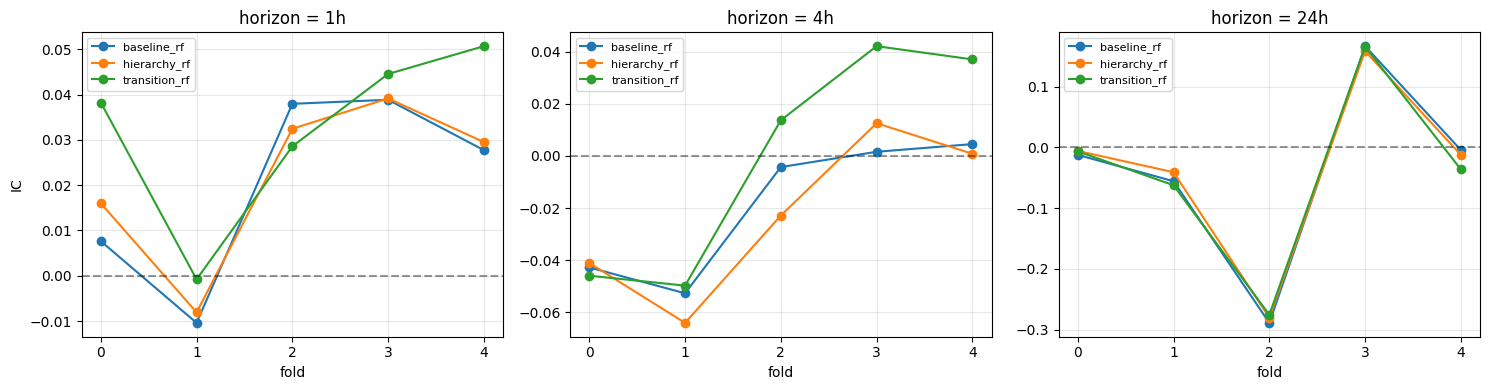

In [10]:
fig, axes = plt.subplots(1, len(HORIZONS), figsize=(5 * len(HORIZONS), 4), sharey=False)
for ax, h in zip(np.atleast_1d(axes), HORIZONS):
    sub = reg[(reg["horizon"] == h) & reg["model"].isin(["baseline_rf", "hierarchy_rf", "transition_rf"])]
    for m in ["baseline_rf", "hierarchy_rf", "transition_rf"]:
        rows = sub[sub["model"] == m].sort_values("fold")
        ax.plot(rows["fold"], rows["ic"], "o-", label=m)
    ax.axhline(0, color="k", linestyle="--", alpha=0.4)
    ax.set_title(f"horizon = {h}h"); ax.set_xlabel("fold"); ax.set_xticks(range(N_FOLDS))
    if ax is np.atleast_1d(axes)[0]: ax.set_ylabel("IC")
    ax.grid(True, alpha=0.3); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()


## Append to EXPERIMENTS.md


In [11]:
def append_to_journal(agg_df, info_pivot, lift_summary, ba_lift, auc_lift, journal_path=JOURNAL_PATH):
    timestamp = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    config = {
        "notebook": "11_two_stage_horizon_sweep.ipynb",
        "ticker": TICKER, "period": PERIOD, "interval": INTERVAL,
        "horizons_hours": HORIZONS, "n_folds": N_FOLDS,
        "f1_f2_split": F1_F2_SPLIT,
        "max_hierarchy_depth": MAX_HIERARCHY_DEPTH,
        "stage1_params": STAGE1_PARAMS, "stage2_params": STAGE2_PARAMS,
        "rf_n_estimators": RF_N_ESTIMATORS, "seed": SEED,
    }
    reg_summary = agg_df[agg_df["kind"] == "regression"].groupby(
        ["horizon", "model"])["ic"].agg(["mean", "std"]).round(5)
    cls_summary = agg_df[agg_df["kind"] == "classification"].groupby(
        ["horizon", "model"])[["balanced_accuracy", "roc_auc"]].agg(["mean", "std"]).round(4)

    parts = ["\n---\n"]
    parts.append(f"\n## {timestamp} — NB11 two-stage horizon sweep (BTC-USD, horizons={HORIZONS}h, K=4)\n")
    parts.append(f"\n**Config**\n\n```json\n{json.dumps(config, indent=2)}\n```\n")
    parts.append("\n**Stage-1 state-prediction sanity per horizon**\n\n")
    parts.append("```\n"); parts.append(str(info_pivot)); parts.append("\n```\n")
    parts.append("\n**IC lift (transition_rf − hierarchy_rf) per horizon**\n\n")
    parts.append("```\n"); parts.append(str(lift_summary)); parts.append("\n```\n")
    parts.append("\n**bal_acc lift in pp (transition − hierarchy) per horizon**\n\n")
    agg_ba = (ba_lift * 100).groupby("horizon").agg(["mean", "std"]).round(3)
    agg_ba["folds_positive"] = (ba_lift > 0).groupby("horizon").sum()
    parts.append("```\n"); parts.append(str(agg_ba)); parts.append("\n```\n")
    parts.append("\n**AUC lift (transition − hierarchy) per horizon**\n\n")
    agg_auc = auc_lift.groupby("horizon").agg(["mean", "std"]).round(5)
    agg_auc["folds_positive"] = (auc_lift > 0).groupby("horizon").sum()
    parts.append("```\n"); parts.append(str(agg_auc)); parts.append("\n```\n")
    parts.append("\n**Regression IC summary (mean ± std across folds)**\n\n")
    parts.append("```\n"); parts.append(str(reg_summary)); parts.append("\n```\n")
    parts.append("\n**Classification summary (mean ± std across folds)**\n\n")
    parts.append("```\n"); parts.append(str(cls_summary)); parts.append("\n```\n")
    text = "".join(parts)
    with open(journal_path, "a") as f:
        f.write(text)
    print(f"Appended entry to {journal_path}")
    return text


journal_text = append_to_journal(agg, info_pivot, lift_summary, ba_lift, auc_lift)


Appended entry to EXPERIMENTS.md
